# 2. Model Training

This notebook trains a transfer-learning classifier on the local training split and monitors validation performance with learning-rate scheduling and early stopping.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

TRAIN_DIR = Path('../data/animals_dataset/train')
VAL_DIR = Path('../data/animals_dataset/val')
MODELS_DIR = Path('../models')
RESULTS_DIR = Path('../results')
MODEL_SAVE_PATH = MODELS_DIR / 'best_model.pth'

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

BATCH_SIZE = 16
LEARNING_RATE = 1e-3
NUM_EPOCHS = 20
PATIENCE = 5
NUM_WORKERS = 0


Using device: cpu


In [2]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

class_names = train_dataset.classes
num_classes = len(class_names)

print(f'Classes ({num_classes}): {class_names}')
print(f'Train samples: {len(train_dataset)}')
print(f'Val samples: {len(val_dataset)}')


Classes (5): ['cat', 'cow', 'deer', 'dog', 'lion']
Train samples: 464
Val samples: 83


In [3]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print('Model ready: ResNet18 transfer learning')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\hp/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:13<00:00, 3.51MB/s]


Model ready: ResNet18 transfer learning
Trainable parameters: 2,565


In [ ]:
def run_epoch(model, loader, criterion, device, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    running_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(is_training):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if is_training:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if is_training:
                loss.backward()
                optimizer.step()
            running_loss += loss.item()
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    return running_loss / len(loader), 100.0 * correct / total


In [5]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
patience_counter = 0

print('Starting training...')
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, device, optimizer=optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(
            {
                'model_state_dict': model.state_dict(),
                'class_names': class_names,
                'best_val_loss': best_val_loss,
                'history': history,
            },
            MODEL_SAVE_PATH,
        )
        print('  Saved best model checkpoint.')
    else:
        patience_counter += 1
        print(f'  No improvement ({patience_counter}/{PATIENCE})')

    if patience_counter >= PATIENCE:
        print(f'Early stopping triggered at epoch {epoch + 1}.')
        break

training_minutes = (time.time() - start_time) / 60
print(f'Training completed in {training_minutes:.2f} minutes')
print(f'Best validation loss: {best_val_loss:.4f}')


Starting training...
Epoch [01/20] Train Loss: 1.3039 | Train Acc: 50.43% | Val Loss: 0.7051 | Val Acc: 85.54%
  Saved best model checkpoint.
Epoch [02/20] Train Loss: 0.6163 | Train Acc: 84.91% | Val Loss: 0.3513 | Val Acc: 97.59%
  Saved best model checkpoint.
Epoch [03/20] Train Loss: 0.3945 | Train Acc: 91.16% | Val Loss: 0.2382 | Val Acc: 97.59%
  Saved best model checkpoint.
Epoch [04/20] Train Loss: 0.3571 | Train Acc: 90.73% | Val Loss: 0.1909 | Val Acc: 97.59%
  Saved best model checkpoint.
Epoch [05/20] Train Loss: 0.2714 | Train Acc: 93.97% | Val Loss: 0.2065 | Val Acc: 97.59%
  No improvement (1/5)
Epoch [06/20] Train Loss: 0.2325 | Train Acc: 94.61% | Val Loss: 0.1354 | Val Acc: 97.59%
  Saved best model checkpoint.
Epoch [07/20] Train Loss: 0.2617 | Train Acc: 93.97% | Val Loss: 0.1342 | Val Acc: 97.59%
  Saved best model checkpoint.
Epoch [08/20] Train Loss: 0.2318 | Train Acc: 93.75% | Val Loss: 0.1372 | Val Acc: 97.59%
  No improvement (1/5)
Epoch [09/20] Train Loss: 0

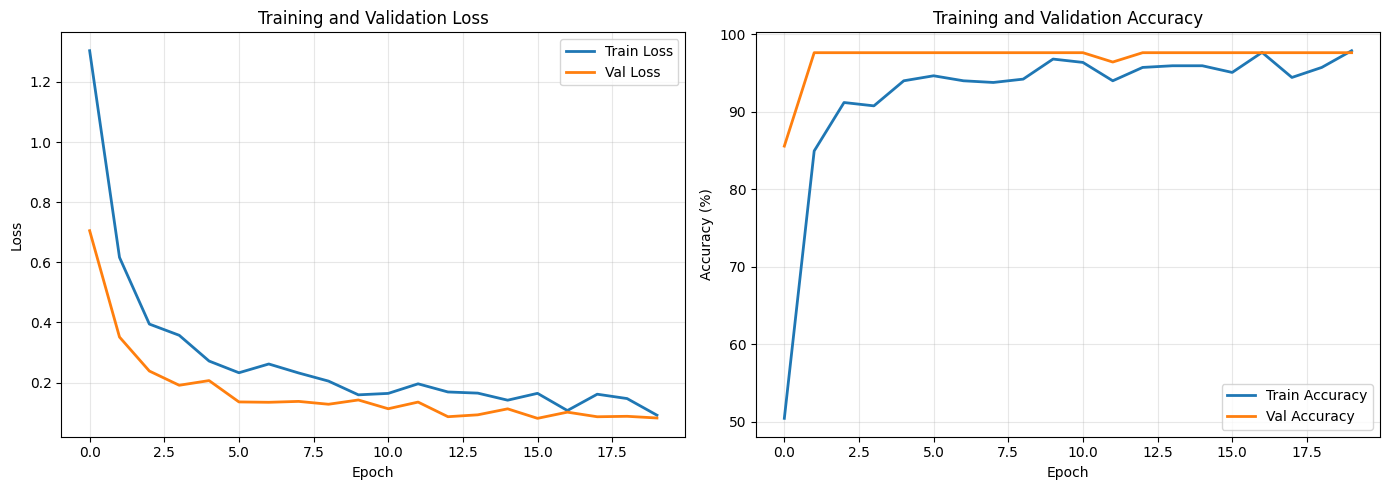

Best model saved to ..\models\best_model.pth


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', linewidth=2)
axes[1].set_title('Training and Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Best model saved to {MODEL_SAVE_PATH}')
